In [10]:
from pathlib import Path


def find_project_root(start=None):
    """Find the repository root by looking for pyproject.toml."""
    path = Path.cwd() if start is None else Path(start)

    for candidate in [path, *path.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate

    raise FileNotFoundError("Project root could not be found.")


PROJECT_ROOT = find_project_root()

DATA_DL3_RAW = PROJECT_ROOT / "data" / "dl3" / "raw"

RESULTS_DL3_DIR = PROJECT_ROOT / "results" / "dl3"
RESULTS_DL3_FIGURES = RESULTS_DL3_DIR / "figures"
RESULTS_DL3_TABLES = RESULTS_DL3_DIR / "tables"

file_path = (
    DATA_DL3_RAW
    / "20131113_05030908_DL3_CrabNebula-W0.40+215.fits"
)

In [11]:
from astropy.io import fits


# Open FITS file
with fits.open(file_path) as hdul:
    
    # Show structure of the FITS file
    hdul.info()

Filename: c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\data\dl3\raw\20131113_05030908_DL3_CrabNebula-W0.40+215.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  EVENTS        1 BinTableHDU     57   13120R x 5C   [1K, 1D, 1E, 1E, 1E]   
  2  GTI           1 BinTableHDU     24   1R x 2C   [1D, 1D]   
  3  RAD_MAX       1 BinTableHDU     33   1R x 5C   [20E, 20E, 1E, 1E, 20E]   
  4  EFFECTIVE AREA    1 BinTableHDU     35   1R x 5C   [28E, 28E, 1E, 1E, 28E]   
  5  ENERGY DISPERSION    1 BinTableHDU     36   1R x 7C   [28E, 28E, 50E, 50E, 1E, 1E, 1400E]   


In [12]:
from astropy.io import fits
from astropy.table import Table


with fits.open(file_path) as hdul:
    events = Table(hdul["EVENTS"].data)

events[:10]

EVENT_ID,TIME,RA,DEC,ENERGY
int64,float64,float32,float32,float32
3081,337231739.77140343,83.22154,21.239828,0.043428835
3124,337231739.9058764,84.52978,22.226255,0.0691374
3182,337231740.02265054,81.065575,20.935791,0.34902474
3206,337231740.0687703,83.2033,20.93657,0.08834142
3230,337231740.13535047,83.00451,21.88527,0.03899335
3249,337231740.1763405,82.780304,21.926056,0.03596863
3250,337231740.1790078,81.99171,21.48037,0.04065514
3289,337231740.31010246,83.348724,21.489805,0.054864127
3312,337231740.3589367,84.091,21.479937,0.1181929


In [13]:
from astropy.io import fits

with fits.open(file_path) as hdul:

    for hdu in hdul[1:]:

        print("\n" + "=" * 70)
        print(f"HDU: {hdu.name}")
        print("=" * 70)

        if hasattr(hdu, "columns"):
            for col in hdu.columns:
                print(
                    f"{col.name:<20} "
                    f"format={col.format:<10} "
                    f"unit={str(col.unit):<10}"
                )


HDU: EVENTS
EVENT_ID             format=1K         unit=None      
TIME                 format=1D         unit=s         
RA                   format=1E         unit=deg       
DEC                  format=1E         unit=deg       
ENERGY               format=1E         unit=TeV       

HDU: GTI
START                format=1D         unit=s         
STOP                 format=1D         unit=s         

HDU: RAD_MAX
ENERG_LO             format=20E        unit=TeV       
ENERG_HI             format=20E        unit=TeV       
THETA_LO             format=1E         unit=deg       
THETA_HI             format=1E         unit=deg       
RAD_MAX              format=20E        unit=deg       

HDU: EFFECTIVE AREA
ENERG_LO             format=28E        unit=TeV       
ENERG_HI             format=28E        unit=TeV       
THETA_LO             format=1E         unit=deg       
THETA_HI             format=1E         unit=deg       
EFFAREA              format=28E        unit=m2        

HDU: E

In [14]:
with fits.open(file_path) as hdul:
    events = hdul["EVENTS"].data

    print(events.columns.names)
    print()
    
    for i in range(5):
        print(events[i])

['EVENT_ID', 'TIME', 'RA', 'DEC', 'ENERGY']

(np.int64(3081), np.float64(337231739.77140343), np.float32(83.22154), np.float32(21.239828), np.float32(0.043428835))
(np.int64(3124), np.float64(337231739.9058764), np.float32(84.52978), np.float32(22.226255), np.float32(0.0691374))
(np.int64(3182), np.float64(337231740.02265054), np.float32(81.065575), np.float32(20.935791), np.float32(0.34902474))
(np.int64(3206), np.float64(337231740.0687703), np.float32(83.2033), np.float32(20.93657), np.float32(0.08834142))
(np.int64(3230), np.float64(337231740.13535047), np.float32(83.00451), np.float32(21.88527), np.float32(0.03899335))


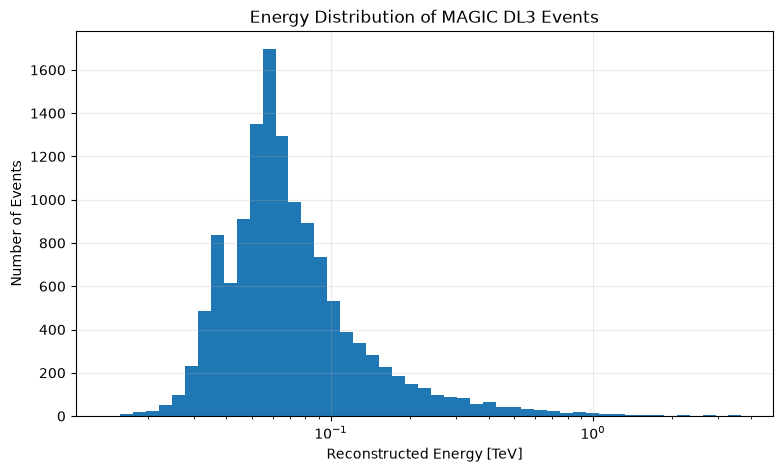

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

with fits.open(file_path) as hdul:
    events = hdul["EVENTS"].data

energy = events["ENERGY"]

# Logarithmic bins are useful because the energies
# span a large range
bins = np.logspace(
    np.log10(energy.min()),
    np.log10(energy.max()),
    50
)

plt.figure(figsize=(9, 5))

plt.hist(energy, bins=bins)

plt.xscale("log")

plt.xlabel("Reconstructed Energy [TeV]")
plt.ylabel("Number of Events")
plt.title("Energy Distribution of MAGIC DL3 Events")

plt.grid(alpha=0.25)
plt.show()

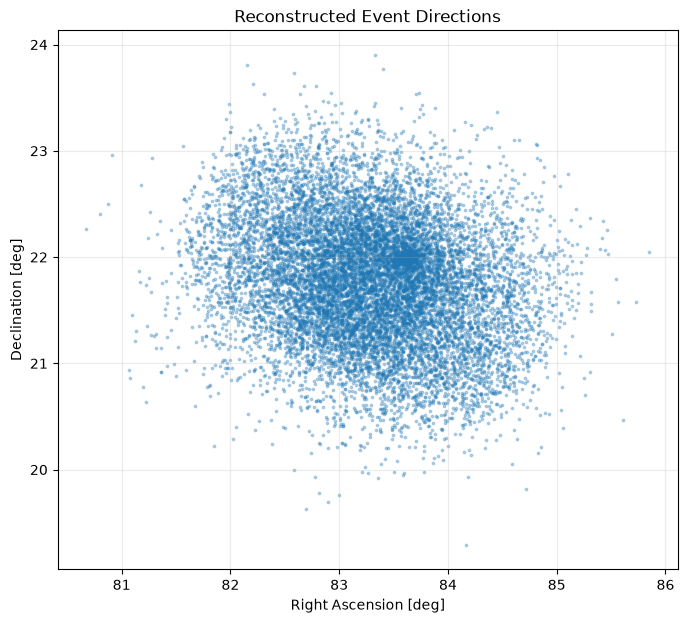

In [16]:
ra = events["RA"]
dec = events["DEC"]

plt.figure(figsize=(8, 7))

plt.scatter(
    ra,
    dec,
    s=3,
    alpha=0.3
)

plt.xlabel("Right Ascension [deg]")
plt.ylabel("Declination [deg]")
plt.title("Reconstructed Event Directions")

plt.grid(alpha=0.25)
plt.show()

Number of events: 13,120
Crab position:
RA  = 83.6331 deg
DEC = 22.0145 deg

Angular separation:
Minimum : 0.0026 deg
Median  : 0.8214 deg
Maximum : 2.7687 deg


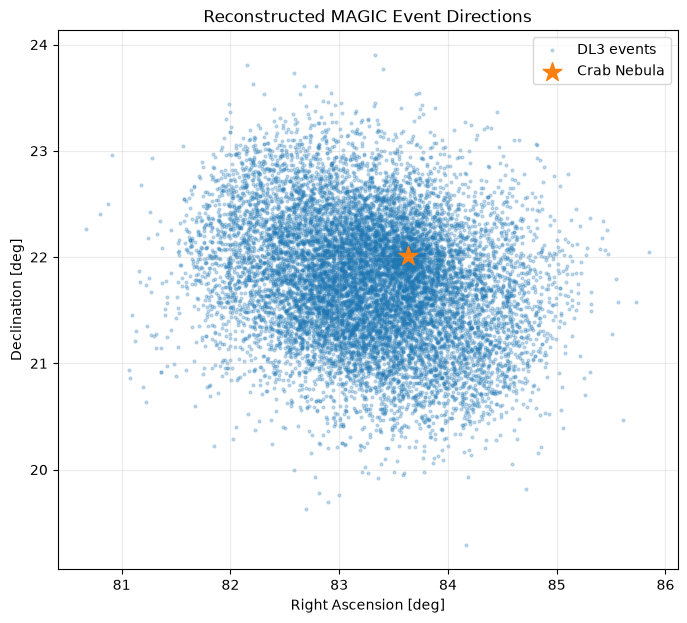

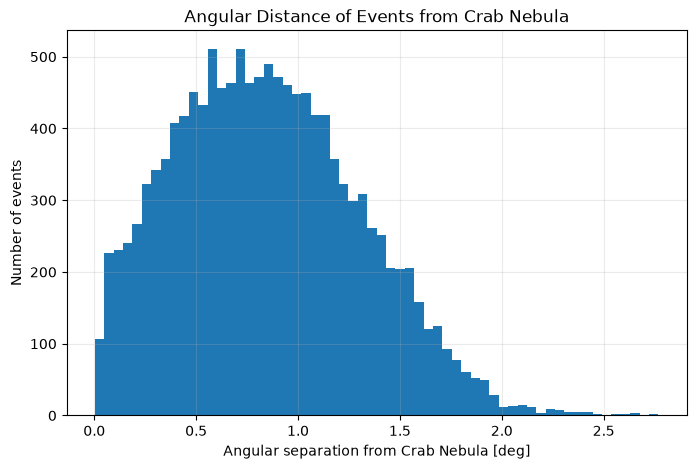

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u

# ------------------------------------------------------------
# 1. Load events
# ------------------------------------------------------------

with fits.open(file_path) as hdul:
    events = hdul["EVENTS"].data

ra = events["RA"]
dec = events["DEC"]
energy = events["ENERGY"]

print(f"Number of events: {len(events):,}")


# ------------------------------------------------------------
# 2. Define Crab Nebula position
# ------------------------------------------------------------

crab = SkyCoord(
    ra=83.6331 * u.deg,
    dec=22.0145 * u.deg,
    frame="icrs"
)

print("Crab position:")
print(f"RA  = {crab.ra.deg:.4f} deg")
print(f"DEC = {crab.dec.deg:.4f} deg")


# ------------------------------------------------------------
# 3. Create coordinates for all reconstructed events
# ------------------------------------------------------------

event_coords = SkyCoord(
    ra=ra * u.deg,
    dec=dec * u.deg,
    frame="icrs"
)


# ------------------------------------------------------------
# 4. Calculate angular separation from Crab Nebula
# ------------------------------------------------------------

separation = event_coords.separation(crab)

# Convert to degrees
theta = separation.deg

print()
print("Angular separation:")
print(f"Minimum : {theta.min():.4f} deg")
print(f"Median  : {np.median(theta):.4f} deg")
print(f"Maximum : {theta.max():.4f} deg")


# ------------------------------------------------------------
# 5. Plot reconstructed event directions
# ------------------------------------------------------------

plt.figure(figsize=(8, 7))

plt.scatter(
    ra,
    dec,
    s=4,
    alpha=0.25,
    label="DL3 events"
)

# Crab position
plt.scatter(
    crab.ra.deg,
    crab.dec.deg,
    marker="*",
    s=200,
    label="Crab Nebula"
)

plt.xlabel("Right Ascension [deg]")
plt.ylabel("Declination [deg]")
plt.title("Reconstructed MAGIC Event Directions")

plt.legend()
plt.grid(alpha=0.25)

plt.show()


# ------------------------------------------------------------
# 6. Histogram of angular distance from Crab
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    theta,
    bins=60
)

plt.xlabel("Angular separation from Crab Nebula [deg]")
plt.ylabel("Number of events")
plt.title("Angular Distance of Events from Crab Nebula")

plt.grid(alpha=0.25)

plt.show()

In [18]:

from astropy.io import fits
import numpy as np


with fits.open(file_path) as hdul:
    rad_data = hdul["RAD_MAX"].data

energy_low = np.squeeze(rad_data["ENERG_LO"])
energy_high = np.squeeze(rad_data["ENERG_HI"])
rad_max = np.squeeze(rad_data["RAD_MAX"])

print("Shapes:")
print("energy_low :", energy_low.shape)
print("energy_high:", energy_high.shape)
print("rad_max    :", rad_max.shape)

print()
print(f"{'E_low [TeV]':>12} {'E_high [TeV]':>13} {'RAD_MAX [deg]':>15}")
print("-" * 44)

for e_low, e_high, r_max in zip(energy_low, energy_high, rad_max):
    print(
        f"{float(e_low):12.4f} "
        f"{float(e_high):13.4f} "
        f"{float(r_max):15.4f}"
    )

Shapes:
energy_low : (20,)
energy_high: (20,)
rad_max    : (20,)

 E_low [TeV]  E_high [TeV]   RAD_MAX [deg]
--------------------------------------------
      0.0100        0.0158          0.1414
      0.0158        0.0251          0.2449
      0.0251        0.0398          0.2646
      0.0398        0.0631          0.2646
      0.0631        0.1000          0.2236
      0.1000        0.1585          0.2000
      0.1585        0.2512          0.1732
      0.2512        0.3981          0.1414
      0.3981        0.6310          0.1000
      0.6310        1.0000          0.1000
      1.0000        1.5849          0.1000
      1.5849        2.5119          0.1000
      2.5119        3.9811          0.1000
      3.9811        6.3096          0.1000
      6.3096       10.0000          0.1000
     10.0000       15.8489          0.1000
     15.8489       25.1189          0.1000
     25.1189       39.8107          0.1000
     39.8107       63.0957          0.1414
     63.0957      100.0000   

In [19]:
import numpy as np
from astropy.io import fits

with fits.open(file_path) as hdul:
    rad_data = hdul["RAD_MAX"].data

energy_low = np.squeeze(rad_data["ENERG_LO"])
energy_high = np.squeeze(rad_data["ENERG_HI"])
rad_max = np.squeeze(rad_data["RAD_MAX"])

print("Shapes:")
print("energy_low :", energy_low.shape)
print("energy_high:", energy_high.shape)
print("rad_max    :", rad_max.shape)

print()
print(f"{'E_low [TeV]':>12} {'E_high [TeV]':>13} {'RAD_MAX [deg]':>15}")
print("-" * 44)

for e_low, e_high, r_max in zip(energy_low, energy_high, rad_max):
    print(f"{float(e_low):12.4f} {float(e_high):13.4f} {float(r_max):15.4f}")

Shapes:
energy_low : (20,)
energy_high: (20,)
rad_max    : (20,)

 E_low [TeV]  E_high [TeV]   RAD_MAX [deg]
--------------------------------------------
      0.0100        0.0158          0.1414
      0.0158        0.0251          0.2449
      0.0251        0.0398          0.2646
      0.0398        0.0631          0.2646
      0.0631        0.1000          0.2236
      0.1000        0.1585          0.2000
      0.1585        0.2512          0.1732
      0.2512        0.3981          0.1414
      0.3981        0.6310          0.1000
      0.6310        1.0000          0.1000
      1.0000        1.5849          0.1000
      1.5849        2.5119          0.1000
      2.5119        3.9811          0.1000
      3.9811        6.3096          0.1000
      6.3096       10.0000          0.1000
     10.0000       15.8489          0.1000
     15.8489       25.1189          0.1000
     25.1189       39.8107          0.1000
     39.8107       63.0957          0.1414
     63.0957      100.0000   

In [20]:
# Find the corresponding RAD_MAX energy bin for each event
bin_index = np.searchsorted(energy_high, energy, side="right")

# Check whether events lie within the RAD_MAX energy range
valid = (
    (energy >= energy_low[0]) &
    (energy < energy_high[-1]) &
    (bin_index < len(rad_max))
)

# Create array for event-specific RAD_MAX values
event_rad_max = np.full(len(energy), np.nan)

event_rad_max[valid] = rad_max[bin_index[valid]]

print(f"All events:                    {len(events):,}")
print(f"Events within RAD_MAX range:   {valid.sum():,}")
print(f"Events outside energy range:   {(~valid).sum():,}")

All events:                    13,120
Events within RAD_MAX range:   13,120
Events outside energy range:   0


In [21]:
# Find the corresponding RAD_MAX energy bin for each event
bin_index = np.searchsorted(energy_high, energy, side="right")

# Check whether events lie within the RAD_MAX energy range
valid = (
    (energy >= energy_low[0]) &
    (energy < energy_high[-1]) &
    (bin_index < len(rad_max))
)

# Create array for event-specific RAD_MAX values
event_rad_max = np.full(len(energy), np.nan)

event_rad_max[valid] = rad_max[bin_index[valid]]

print(f"All events:                    {len(events):,}")
print(f"Events within RAD_MAX range:   {valid.sum():,}")
print(f"Events outside energy range:   {(~valid).sum():,}")

All events:                    13,120
Events within RAD_MAX range:   13,120
Events outside energy range:   0


In [22]:
on_mask = valid & (theta < event_rad_max)

print(f"\nEvents inside ON region: {on_mask.sum():,}")
print(f"Fraction inside ON region: {on_mask.sum() / valid.sum():.2%}")


Events inside ON region: 1,088
Fraction inside ON region: 8.29%


In [23]:
print(
    f"{'Energy [TeV]':>14} "
    f"{'Theta [deg]':>12} "
    f"{'RAD_MAX [deg]':>15} "
    f"{'Inside':>8}"
)

print("-" * 55)

for i in range(20):
    print(
        f"{energy[i]:14.4f} "
        f"{theta[i]:12.4f} "
        f"{event_rad_max[i]:15.4f} "
        f"{str(on_mask[i]):>8}"
    )

  Energy [TeV]  Theta [deg]   RAD_MAX [deg]   Inside
-------------------------------------------------------
        0.0434       0.8640          0.2646    False
        0.0691       0.8572          0.2236    False
        0.3490       2.6214          0.1414    False
        0.0883       1.1497          0.2236    False
        0.0390       0.5972          0.2646    False
        0.0360       0.7958          0.2646    False
        0.0407       1.6154          0.2646    False
        0.0549       0.5874          0.2646    False
        0.1182       0.6831          0.2000    False
        0.0416       0.6072          0.2646    False
        0.0645       0.3199          0.2236    False
        0.0715       0.5688          0.2236    False
        0.0613       0.6764          0.2646    False
        0.0549       1.2148          0.2646    False
        0.0777       1.2280          0.2236    False
        0.0815       1.2148          0.2236    False
        0.0813       0.5561          0.2236

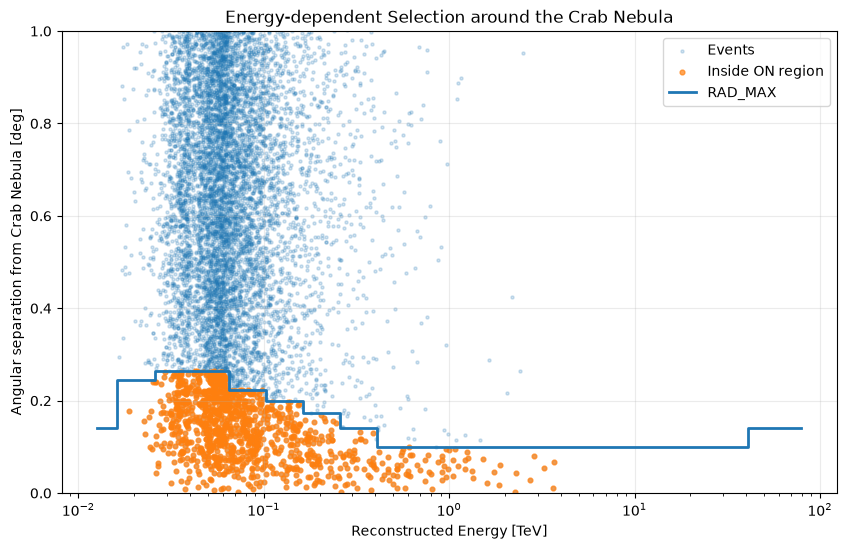

In [24]:
plt.figure(figsize=(10, 6))

# All valid events
plt.scatter(
    energy[valid],
    theta[valid],
    s=5,
    alpha=0.2,
    label="Events"
)

# Events inside ON region
plt.scatter(
    energy[on_mask],
    theta[on_mask],
    s=12,
    alpha=0.7,
    label="Inside ON region"
)

# RAD_MAX curve
energy_center = np.sqrt(energy_low * energy_high)

plt.step(
    energy_center,
    rad_max,
    where="mid",
    linewidth=2,
    label="RAD_MAX"
)

plt.xscale("log")

# Zoom into the interesting angular region
plt.ylim(0, 1)

plt.xlabel("Reconstructed Energy [TeV]")
plt.ylabel("Angular separation from Crab Nebula [deg]")
plt.title("Energy-dependent Selection around the Crab Nebula")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

In [25]:
on_mask = valid & (theta < event_rad_max)

print(f"Events inside ON region: {on_mask.sum():,}")
print(f"Fraction inside ON region: {on_mask.sum() / valid.sum():.2%}")


Events inside ON region: 1,088
Fraction inside ON region: 8.29%


In [26]:
with fits.open(file_path) as hdul:
    header = hdul["EVENTS"].header

    keywords = [
        "OBJECT",
        "RA_OBJ",
        "DEC_OBJ",
        "RA_PNT",
        "DEC_PNT",
        "ALT_PNT",
        "AZ_PNT",
        "OBS_ID",
        "TSTART",
        "TSTOP",
        "LIVETIME",
        "ONTIME",
        "DEADC"
    ]

    for key in keywords:
        print(f"{key:<10}: {header.get(key)}")
        

OBJECT    : CrabNebula
RA_OBJ    : 83.63333
DEC_OBJ   : 22.01444
RA_PNT    : 83.27917
DEC_PNT   : 21.78389
ALT_PNT   : 81.23988
AZ_PNT    : 217.4651
OBS_ID    : 5030908
TSTART    : 337231739.771403
TSTOP     : 337232923.872518
LIVETIME  : 1175.18996679776
ONTIME    : 1184.10111486912
DEADC     : 0.9924743


In [27]:
from astropy.coordinates import SkyCoord
import astropy.units as u

source = SkyCoord(
    ra=83.63333 * u.deg,
    dec=22.01444 * u.deg,
    frame="icrs"
)

pointing = SkyCoord(
    ra=83.27917 * u.deg,
    dec=21.78389 * u.deg,
    frame="icrs"
)

wobble_offset = source.separation(pointing)

print(f"Wobble offset: {wobble_offset.deg:.4f} deg")

Wobble offset: 0.4014 deg


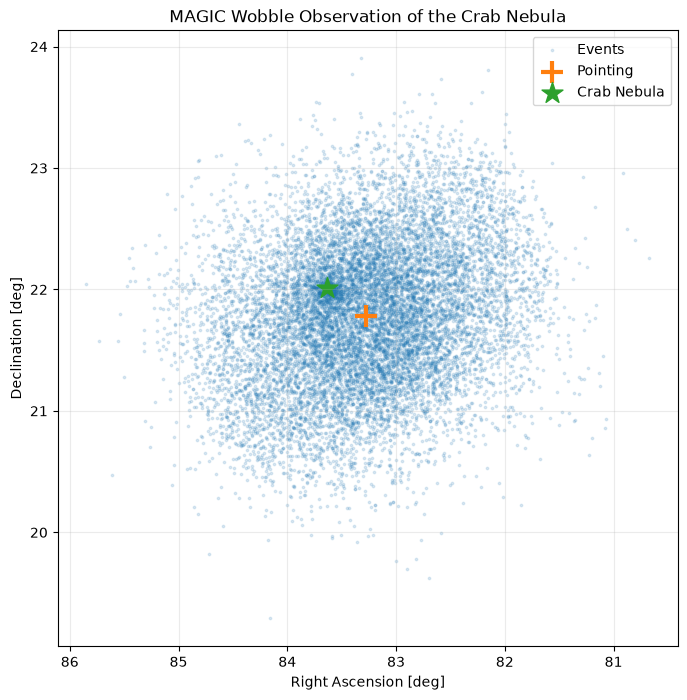

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

# All reconstructed events
plt.scatter(
    ra,
    dec,
    s=3,
    alpha=0.15,
    label="Events"
)

# Telescope pointing direction
plt.scatter(
    pointing.ra.deg,
    pointing.dec.deg,
    marker="+",
    s=250,
    linewidth=3,
    label="Pointing"
)

# Crab Nebula
plt.scatter(
    source.ra.deg,
    source.dec.deg,
    marker="*",
    s=250,
    label="Crab Nebula"
)

plt.xlabel("Right Ascension [deg]")
plt.ylabel("Declination [deg]")
plt.title("MAGIC Wobble Observation of the Crab Nebula")

plt.legend()
plt.grid(alpha=0.25)

# Astronomical convention:
# Right Ascension increases towards the left
plt.gca().invert_xaxis()

plt.show()

In [29]:
import gammapy

print("Gammapy version:", gammapy.__version__)

Gammapy version: 2.1


In [30]:
from gammapy.data import Observation

obs = Observation.read(file_path)

print(obs)

'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.


Observation

	obs id            : 5030908 
 	tstart            : 56609.15
	tstop             : 56609.16
	duration          : 1184.10 s
	pointing (icrs)   : 83.3 deg, 21.8 deg

	deadtime fraction : 0.8%



In [31]:
import gammapy
import regions
import astropy
import numpy

print("Gammapy:", gammapy.__version__)
print("regions:", regions.__version__)
print("Astropy:", astropy.__version__)
print("NumPy:", numpy.__version__)

Gammapy: 2.1
regions: 0.11
Astropy: 8.0.1
NumPy: 2.5.3


In [32]:
%pip install "regions==0.11"


Note: you may need to restart the kernel to use updated packages.


In [33]:
import os
print(os.getpid())

19872


In [34]:
from gammapy.data import Observation

obs = Observation.read(file_path)

print(obs)

'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.


Observation

	obs id            : 5030908 
 	tstart            : 56609.15
	tstop             : 56609.16
	duration          : 1184.10 s
	pointing (icrs)   : 83.3 deg, 21.8 deg

	deadtime fraction : 0.8%



In [35]:
print("Observation ID:", obs.obs_id)
print("Number of events:", len(obs.events.table))
print("Livetime:", obs.observation_live_time_duration)

print("\nAvailable HDUs:")
print(obs.available_hdus)

print("\nAvailable IRFs:")
print(obs.available_irfs)


Observation ID: 5030908
Number of events: 13120
Livetime: 1175.1899251089499 s

Available HDUs:
['events', 'gti', 'aeff', 'edisp', 'rad_max']

Available IRFs:
['aeff', 'edisp', 'rad_max']


In [36]:
print(obs.rad_max)

RadMax2D
--------

  axes  : ['energy', 'offset']
  shape : (20, 1)
  ndim  : 2
  unit  : deg
  dtype : >f4



In [37]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from regions import PointSkyRegion

from gammapy.datasets import SpectrumDataset
from gammapy.maps import MapAxis, RegionGeom
from gammapy.makers import (
    SpectrumDatasetMaker,
    ReflectedRegionsBackgroundMaker,
    SafeMaskMaker,
    WobbleRegionsFinder,
)

# Crab Nebula position
target_position = SkyCoord(
    ra=83.63333,
    dec=22.01444,
    unit="deg",
    frame="icrs"
)

# Important for energy-dependent RAD_MAX:
# use PointSkyRegion, not CircleSkyRegion
on_region = PointSkyRegion(target_position)


In [38]:
energy_axis = MapAxis.from_energy_bounds(
    50,
    1e5,
    nbin=5,
    per_decade=True,
    unit="GeV",
    name="energy",
)

energy_axis_true = MapAxis.from_energy_bounds(
    10,
    1e5,
    nbin=10,
    per_decade=True,
    unit="GeV",
    name="energy_true",
)

In [39]:
geom = RegionGeom.create(
    region=on_region,
    axes=[energy_axis]
)

dataset_empty = SpectrumDataset.create(
    geom=geom,
    energy_axis_true=energy_axis_true
)

In [40]:
dataset_maker = SpectrumDatasetMaker(
    containment_correction=False,
    selection=["counts", "exposure", "edisp"]
)

# Fixed wobble OFF positions
region_finder = WobbleRegionsFinder(
    n_off_regions=3
)

bkg_maker = ReflectedRegionsBackgroundMaker(
    region_finder=region_finder
)

# Use safe-energy information from the DL3 IRFs
safe_mask_maker = SafeMaskMaker(
    methods=["aeff-default"]
)

In [41]:
dataset = dataset_maker.run(
    dataset_empty.copy(name=str(obs.obs_id)),
    obs
)

dataset_on_off = bkg_maker.run(
    dataset,
    obs
)

dataset_on_off = safe_mask_maker.run(
    dataset_on_off,
    obs
)

print(dataset_on_off)

No default upper safe energy threshold defined for obs 5030908


SpectrumDatasetOnOff
--------------------

  Name                            : 5030908 

  Total counts                    : 426 
  Total background counts         : 148.67
  Total excess counts             : 277.33

  Predicted counts                : 218.00
  Predicted background counts     : 218.00
  Predicted excess counts         : nan

  Exposure min                    : 1.69e+04 m2 s
  Exposure max                    : 1.26e+08 m2 s

  Number of total bins            : 17 
  Number of fit bins              : 16 

  Fit statistic type              : wstat
  Fit statistic value (-2 log(L)) : 388.28

  Number of models                : 0 
  Number of parameters            : 0
  Number of free parameters       : 0

  Total counts_off                : 446 
  Acceptance                      : 16 
  Acceptance off                  : 48 



In [42]:
info = dataset_on_off.info_dict()

for key, value in info.items():
    print(f"{key}: {value}")

name: 5030908
counts: 426
excess: 277.33333333333337
sqrt_ts: 15.14414993412558
background: 148.66666666666666
npred: 218.0
npred_background: 218.0
npred_signal: nan
exposure_min: 16863.34347631359 m2 s
exposure_max: 125665680.77513853 m2 s
livetime: 1175.1899251089499 s
ontime: 1184.1011148691205 s
counts_rate: 0.3624945984458693 1 / s
background_rate: 0.12650437473150056 1 / s
excess_rate: 0.23599022371436879 1 / s
n_bins: 17
n_fit_bins: 16
stat_type: wstat
stat_sum: 388.28311138456576
counts_off: 446
acceptance: 16.0
acceptance_off: 48.0
alpha: 0.3333333333333333


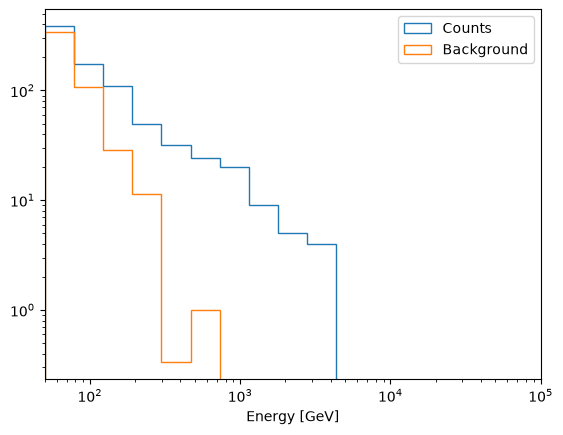

In [43]:
import matplotlib.pyplot as plt

dataset_on_off.plot_counts()

plt.show()

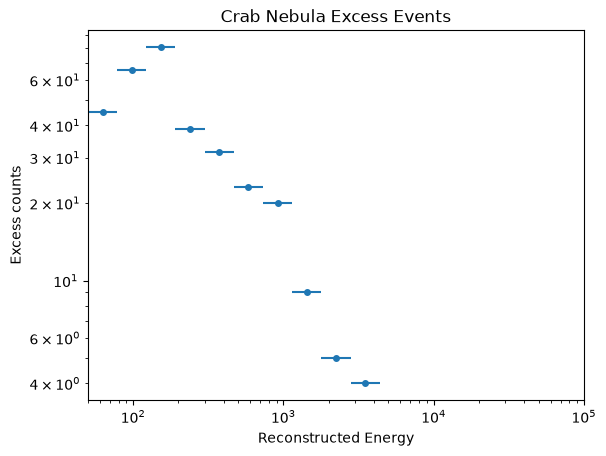

In [44]:
dataset_on_off.excess.plot()

plt.xlabel("Reconstructed Energy")
plt.ylabel("Excess counts")
plt.title("Crab Nebula Excess Events")

plt.show()


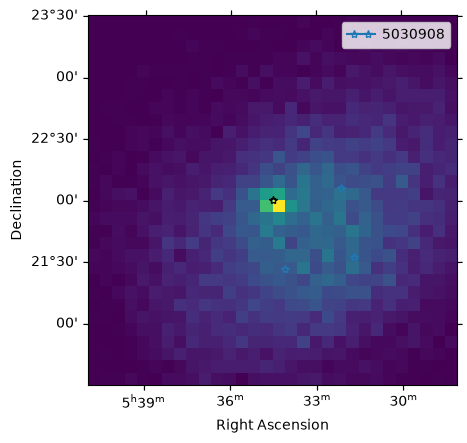

In [45]:
import matplotlib.pyplot as plt

from gammapy.maps import Map
from gammapy.datasets import Datasets
from gammapy.visualization import plot_spectrum_datasets_off_regions

# Put our single reduced run into a Datasets container
datasets_single = Datasets([dataset_on_off])

# Create a sky counts map around the Crab
counts_map = Map.create(
    skydir=target_position,
    width=3
)

# Fill map with all events of the observation
counts_map.fill_events(obs.events)

# Plot event map
ax = counts_map.plot(cmap="viridis")

# Plot Crab position
geom.plot_region(
    ax=ax,
    kwargs_point={"color": "k", "marker": "*"}
)

# Plot OFF regions
plot_spectrum_datasets_off_regions(
    ax=ax,
    datasets=datasets_single
)

plt.show()

In [46]:
print(dataset_on_off.counts_off)
print(dataset_on_off.acceptance)
print(dataset_on_off.acceptance_off)

RegionNDMap

	geom  : RegionGeom 
 	axes  : ['lon', 'lat', 'energy']
	shape : (1, 1, 17)
	ndim  : 3
	unit  : 
	dtype : float32

RegionNDMap

	geom  : RegionGeom 
 	axes  : ['lon', 'lat', 'energy']
	shape : (1, 1, 17)
	ndim  : 3
	unit  : 
	dtype : int64

RegionNDMap

	geom  : RegionGeom 
 	axes  : ['lon', 'lat', 'energy']
	shape : (1, 1, 17)
	ndim  : 3
	unit  : 
	dtype : int64



In [47]:
import numpy as np
import pandas as pd

# Energy axis
energy_axis = dataset_on_off.counts.geom.axes["energy"]

energy_min = energy_axis.edges[:-1].to_value("TeV")
energy_max = energy_axis.edges[1:].to_value("TeV")

# Values per energy bin
counts_on = dataset_on_off.counts.data.squeeze()
counts_off = dataset_on_off.counts_off.data.squeeze()

acceptance = dataset_on_off.acceptance.data.squeeze()
acceptance_off = dataset_on_off.acceptance_off.data.squeeze()

alpha = dataset_on_off.alpha.data.squeeze()

background = dataset_on_off.background.data.squeeze()
excess = dataset_on_off.excess.data.squeeze()

# Safe-energy mask
if dataset_on_off.mask_safe is not None:
    mask_safe = dataset_on_off.mask_safe.data.squeeze()
else:
    mask_safe = np.ones_like(counts_on, dtype=bool)

table = pd.DataFrame({
    "E_min_TeV": energy_min,
    "E_max_TeV": energy_max,
    "ON": counts_on,
    "OFF": counts_off,
    "alpha": alpha,
    "background": background,
    "excess": excess,
    "safe": mask_safe
})

table

,E_min_TeV,E_max_TeV,ON,OFF,alpha,background,excess,safe
0,0.050000,0.078189,385.0,1020.0,0.333333,340.000000,45.000000,False
1,0.078189,0.122272,173.0,322.0,0.333333,107.333333,65.666667,True
2,0.122272,0.191207,109.0,86.0,0.333333,28.666667,80.333333,True
3,0.191207,0.299008,50.0,34.0,0.333333,11.333333,38.666667,True
4,0.299008,0.467586,32.0,1.0,0.333333,0.333333,31.666667,True
5,0.467586,0.731205,24.0,3.0,0.333333,1.000000,23.000000,True
6,0.731205,1.143451,20.0,0.0,0.333333,0.000000,20.000000,True
7,1.143451,1.788117,9.0,0.0,0.333333,0.000000,9.000000,True
8,1.788117,2.796238,5.0,0.0,0.333333,0.000000,5.000000,True
9,2.796238,4.372727,4.0,0.0,0.333333,0.000000,4.000000,True


In [48]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [49]:
safe_table = table[table["safe"]].copy()

safe_table["E_center_TeV"] = np.sqrt(
    safe_table["E_min_TeV"] *
    safe_table["E_max_TeV"]
)

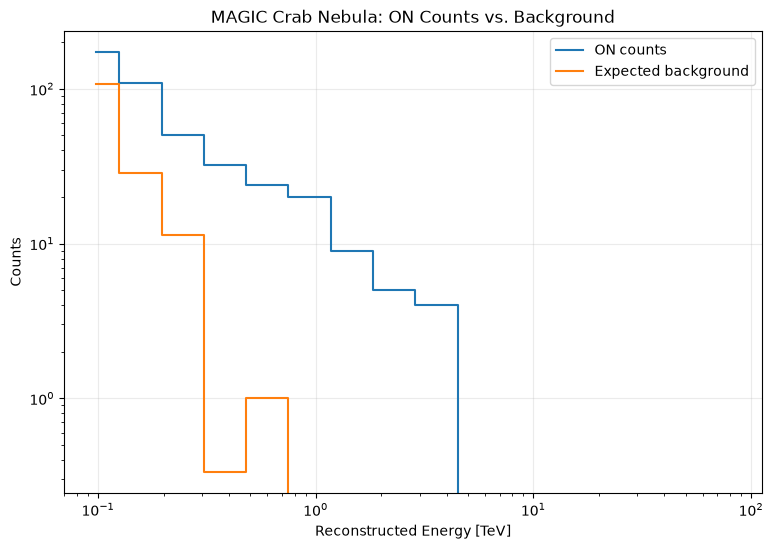

In [50]:
plt.figure(figsize=(9, 6))

plt.step(
    safe_table["E_center_TeV"],
    safe_table["ON"],
    where="mid",
    label="ON counts"
)

plt.step(
    safe_table["E_center_TeV"],
    safe_table["background"],
    where="mid",
    label="Expected background"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Reconstructed Energy [TeV]")
plt.ylabel("Counts")
plt.title("MAGIC Crab Nebula: ON Counts vs. Background")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

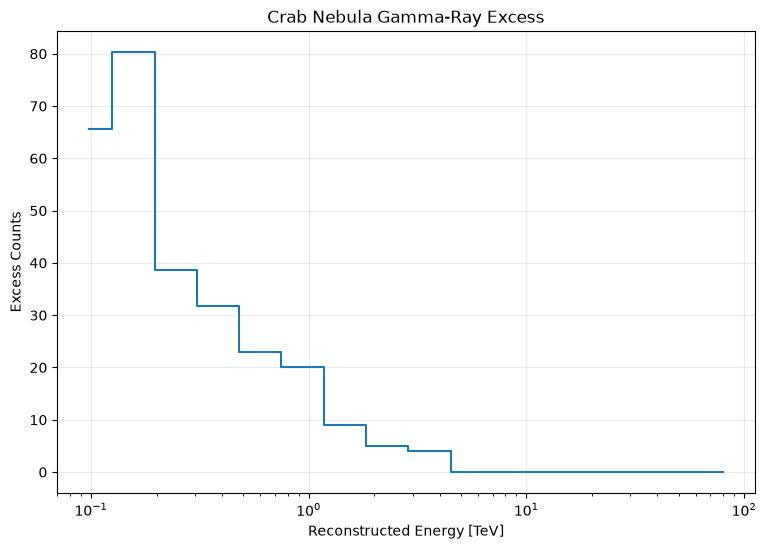

In [51]:
plt.figure(figsize=(9, 6))

plt.step(
    safe_table["E_center_TeV"],
    safe_table["excess"],
    where="mid"
)

plt.xscale("log")

plt.xlabel("Reconstructed Energy [TeV]")
plt.ylabel("Excess Counts")
plt.title("Crab Nebula Gamma-Ray Excess")

plt.grid(alpha=0.25)

plt.show()

In [52]:
import numpy as np
import pandas as pd
import astropy.units as u

from astropy.coordinates import SkyCoord
from regions import PointSkyRegion

from gammapy.data import Observation
from gammapy.datasets import SpectrumDataset, Datasets
from gammapy.maps import MapAxis, RegionGeom
from gammapy.makers import (
    SpectrumDatasetMaker,
    ReflectedRegionsBackgroundMaker,
    SafeMaskMaker,
    WobbleRegionsFinder,
)


# ------------------------------------------------------------
# Target: Crab Nebula
# ------------------------------------------------------------

target_position = SkyCoord(
    ra=83.63333,
    dec=22.01444,
    unit="deg",
    frame="icrs",
)

# PointSkyRegion is important because MAGIC supplies
# an energy-dependent RAD_MAX
on_region = PointSkyRegion(target_position)


# ------------------------------------------------------------
# Reconstructed and true energy axes
# ------------------------------------------------------------

energy_axis = MapAxis.from_energy_bounds(
    50,
    1e5,
    nbin=5,
    per_decade=True,
    unit="GeV",
    name="energy",
)

energy_axis_true = MapAxis.from_energy_bounds(
    10,
    1e5,
    nbin=10,
    per_decade=True,
    unit="GeV",
    name="energy_true",
)


# ------------------------------------------------------------
# Empty template dataset
# ------------------------------------------------------------

geom = RegionGeom.create(
    region=on_region,
    axes=[energy_axis],
)

dataset_empty = SpectrumDataset.create(
    geom=geom,
    energy_axis_true=energy_axis_true,
)


# ------------------------------------------------------------
# Makers
# ------------------------------------------------------------

dataset_maker = SpectrumDatasetMaker(
    containment_correction=False,
    selection=["counts", "exposure", "edisp"],
)

# Three reflected OFF regions
region_finder = WobbleRegionsFinder(
    n_off_regions=3
)

bkg_maker = ReflectedRegionsBackgroundMaker(
    region_finder=region_finder
)

safe_mask_maker = SafeMaskMaker(
    methods=["aeff-default"]
)

In [53]:
def process_magic_run(file_path):
    """
    Process one MAGIC DL3 observation.

    Parameters
    ----------
    file_path : str or pathlib.Path
        Path to a MAGIC DL3 FITS file.

    Returns
    -------
    dataset_on_off : SpectrumDatasetOnOff
        Reduced ON/OFF dataset.

    summary : dict
        Main statistics of the observation.

    observation : Observation
        Original Gammapy observation.
    """

    # --------------------------------------------------------
    # 1. Read observation
    # --------------------------------------------------------

    observation = Observation.read(file_path)


    # --------------------------------------------------------
    # 2. Create spectral dataset
    # --------------------------------------------------------

    dataset = dataset_maker.run(
        dataset_empty.copy(name=str(observation.obs_id)),
        observation
    )


    # --------------------------------------------------------
    # 3. Determine reflected OFF regions
    # --------------------------------------------------------

    dataset_on_off = bkg_maker.run(
        dataset,
        observation
    )


    # --------------------------------------------------------
    # 4. Apply safe energy mask
    # --------------------------------------------------------

    dataset_on_off = safe_mask_maker.run(
        dataset_on_off,
        observation
    )


    # --------------------------------------------------------
    # 5. Extract summary statistics
    # --------------------------------------------------------

    info = dataset_on_off.info_dict()

    summary = {
    "obs_id": int(observation.obs_id),
    "file": str(file_path),

    "livetime_s": float(info["livetime"].to_value("s")),
    "livetime_min": float(info["livetime"].to_value("min")),

    "counts_on": int(info["counts"]),
    "counts_off": int(info["counts_off"]),

    "alpha": float(info["alpha"]),
    "background": float(info["background"]),
    "excess": float(info["excess"]),

    "significance": float(info["sqrt_ts"]),

    "n_bins": int(info["n_bins"]),
    "n_fit_bins": int(info["n_fit_bins"]),
    }

    return dataset_on_off, summary, observation


In [54]:
dataset_test, summary_test, obs_test = process_magic_run(file_path)

summary_test

'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
No default upper safe energy threshold defined for obs 5030908


{'obs_id': 5030908,
 'file': 'c:\\Users\\moonp\\Documents\\Beruflich\\Weiterbildung\\Stackfuel - Data Science\\Portfolio Projekt\\data\\dl3\\raw\\20131113_05030908_DL3_CrabNebula-W0.40+215.fits',
 'livetime_s': 1175.1899251089499,
 'livetime_min': 19.58649875181583,
 'counts_on': 426,
 'counts_off': 446,
 'alpha': 0.3333333333333333,
 'background': 148.66666666666666,
 'excess': 277.33333333333337,
 'significance': 15.14414993412558,
 'n_bins': 17,
 'n_fit_bins': 16}

In [55]:
fits_files = sorted(DATA_DL3_RAW.glob("*DL3*.fits"))

print(f"Found {len(fits_files)} DL3 files")

for file in fits_files[:10]:
    print(file.name)

Found 1 DL3 files
20131113_05030908_DL3_CrabNebula-W0.40+215.fits


In [56]:
print("Project root:", PROJECT_ROOT)
print("DL3 directory:", DATA_DL3_RAW)
print("FITS exists:", file_path.exists())
print("Number of DL3 files:", len(fits_files))


Project root: c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt
DL3 directory: c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\data\dl3\raw
FITS exists: True
Number of DL3 files: 1


In [57]:
dataset_test, summary_test, obs_test = process_magic_run(file_path)

summary_test


'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
'THETA' axis is stored as a scalar -- converting to 1D array.
No default upper safe energy threshold defined for obs 5030908


{'obs_id': 5030908,
 'file': 'c:\\Users\\moonp\\Documents\\Beruflich\\Weiterbildung\\Stackfuel - Data Science\\Portfolio Projekt\\data\\dl3\\raw\\20131113_05030908_DL3_CrabNebula-W0.40+215.fits',
 'livetime_s': 1175.1899251089499,
 'livetime_min': 19.58649875181583,
 'counts_on': 426,
 'counts_off': 446,
 'alpha': 0.3333333333333333,
 'background': 148.66666666666666,
 'excess': 277.33333333333337,
 'significance': 15.14414993412558,
 'n_bins': 17,
 'n_fit_bins': 16}

In [ ]:
import os
os.getpid()

19872

: 